# <a id='toc1_'></a>[Digital signal processing. Lab6](#toc0_)

In [3]:
%%capture 
%pip install matplotlib 
%pip install numpy
%pip install seaborn
%pip install scipy

**Table of contents**<a id='toc0_'></a>    
- [Digital signal processing. Lab6](#toc1_)    
  - [Task1](#toc1_1_)    
  - [Task2](#toc1_2_)    
  - [Task3](#toc1_3_)    
  - [Task4](#toc1_4_)    
    - [Справка: Медианный фильтр для удаления импульсного шума (Spike Noise)](#toc1_4_1_)    
  - [Task5](#toc1_5_)    
    - [Справка: Критерий Байесовской информации (Bayes Information Criterion)](#toc1_5_1_)    
  - [Task6](#toc1_6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [103]:
f1, f2, f3 = 2.5, 8.0, 0.8

Fs = 1000 
dt_1 = 1.0 / Fs

w_1 = 2 * np.pi * f1
w_2 = 2 * np.pi * f2
w_3 = 2 * np.pi * f3

signal_clean = lambda t : 2.0 * np.sin(w_1 * t) + 1.2 * np.sin(w_2 * t) + 0.8 * np.sin(w_3 * t)
               
t_vals = np.arange(0, 10, dt_1)
signal_vals_1 = signal_clean(t_vals)
N = signal_vals_1.shape[-1]

np.random.seed(42)
noise_amplitude = 0.8

signal_vals_noise = signal_vals_1 + noise_amplitude * np.random.normal(0, 1, N)

In [124]:
def compute_spectrum(signal, fs):
    N = len(signal)
    freqs = np.fft.fftfreq(N, 1/fs)[:N//2]
    spectrum = 2/N * np.abs(np.fft.fft(signal))[:N//2]
    return freqs, spectrum

In [105]:
f_clean, spec_clean = compute_spectrum(signal_vals_1, Fs)

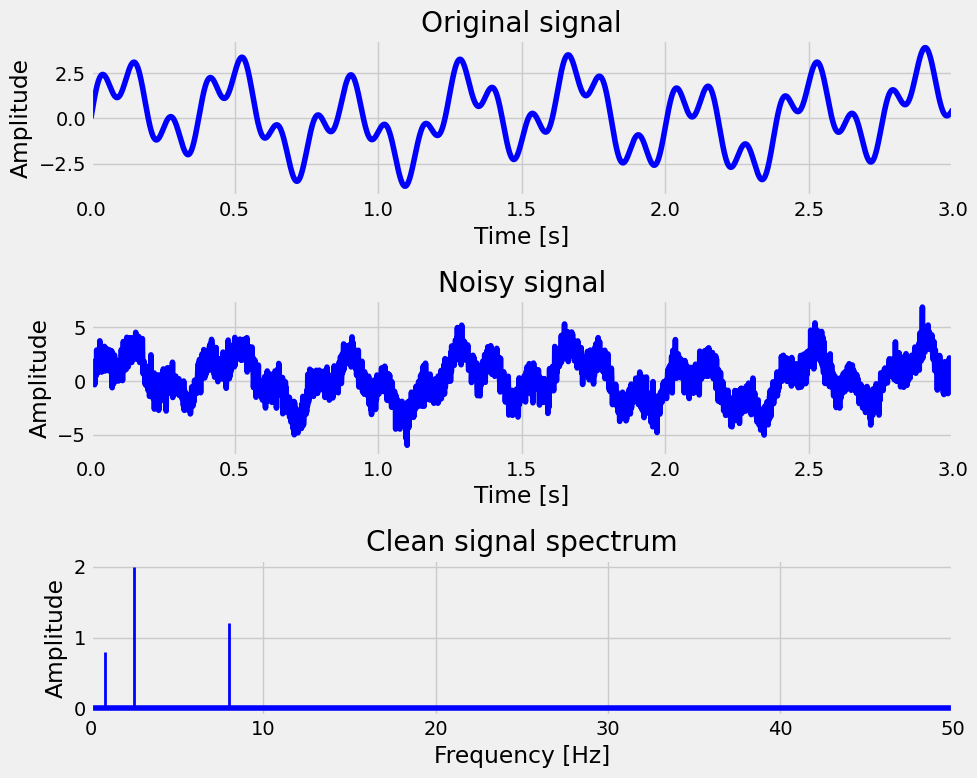

<Figure size 640x480 with 0 Axes>

In [106]:
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t_vals, signal_vals_1, 'b')
plt.title('Original signal')
plt.xlabel('Time [s]')
plt.xlim(0, 3)
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
plt.plot(t_vals, signal_vals_noise, 'b')
plt.title('Noisy signal')
plt.xlabel('Time [s]')
plt.xlim(0, 3)
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
markerline, stemlines, baseline = plt.stem(f_clean, spec_clean)

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Clean signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

## <a id='toc1_1_'></a>[Task1](#toc0_)
Реализовать усреднение зашумленного сигнала по формуле 1. Результат усреднения представлен на рис. 1. Вывести спектр усредненного и зашумленного сигнала. Объяснить результат.

$$y_t = (2k + 1)^{-1} \sum_{i=t-k}^{t+k} x_i \quad (1)$$

*Формула 1 (Running-mean filter)*

---

In [107]:
def running_mean(signal,window_width):
    
    result = np.zeros_like(signal)
    k = (window_width - 1) // 2
    
    for t in range (len(signal)):
        left = max(0, t - k)
        right = min(len(signal), t + k + 1)
        result[t] = 1/window_width * np.sum(signal[left:right])
    
    return result

In [108]:
# перевод миллисекунд в сэмплы

k_ms = 41
k_samples = int((k_ms / 1000) * Fs)  # 41 мс = 41 отсчет при Fs=1000

# (2k + 1) в формлуе подразумевает скользящее окно нечетной длины
if k_samples % 2 == 0: k_samples += 1  

In [109]:
window_width = k_samples
signal_avg_mean = running_mean(signal_vals_noise, window_width)

In [110]:
f_noisy, spec_noisy = compute_spectrum(signal_vals_noise, Fs)
f_avg_mean, spec_avg_mean = compute_spectrum(signal_avg_mean, Fs)

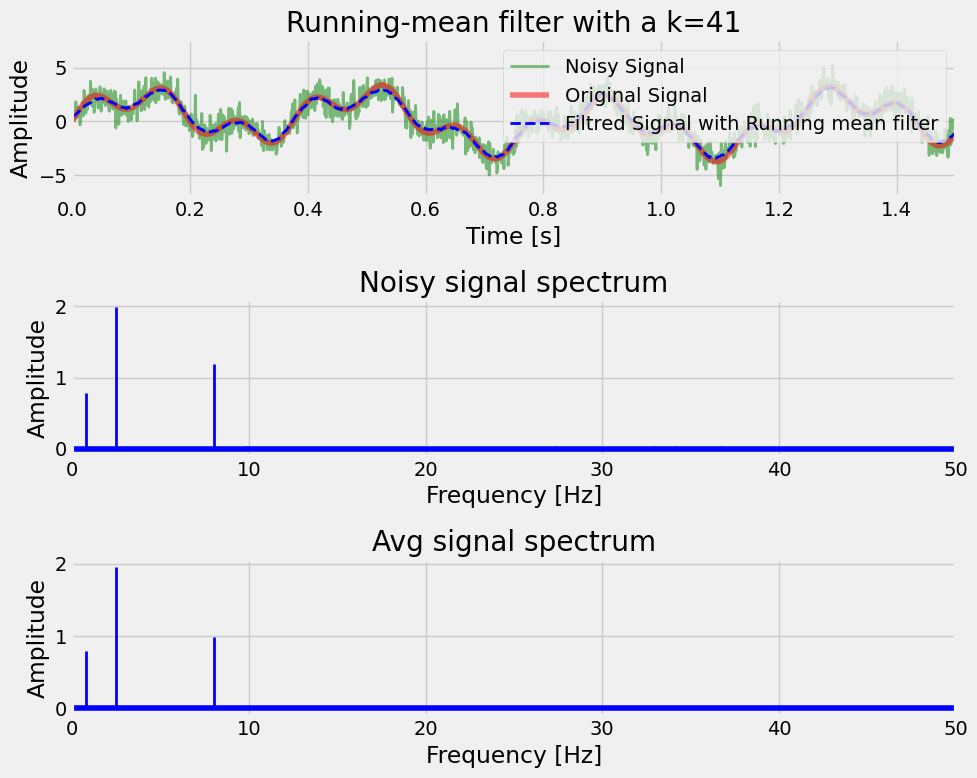

In [111]:
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t_vals, signal_vals_noise, 'g-', alpha=0.5, linewidth=2, label='Noisy Signal')
plt.plot(t_vals, signal_vals_1, 'r-', linewidth=4, alpha=0.5, label='Original Signal')
plt.plot(t_vals, signal_avg_mean, 'b--', linewidth=2, label=f'Filtred Signal with Running mean filter')

plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title(f'Running-mean filter with a k={k_ms}')
plt.legend(loc='upper right')
plt.xlim(0, 1.5)

plt.subplot(3, 1, 2)
markerline, stemlines, baseline = plt.stem(f_noisy, spec_noisy)

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Noisy signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, 50)
plt.tight_layout()

plt.subplot(3, 1, 3)
markerline, stemlines, baseline = plt.stem(f_avg_mean, spec_avg_mean)

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Avg signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

## <a id='toc1_2_'></a>[Task2](#toc0_)
Реализовать усреднение зашумленного сигнала по формуле 2. Результат усреднения представлен на рис. 2. Вывести спектр усредненного и зашумленного сигнала. Сопоставить усреднение по Гауссу и среднему значению, как это сделано на рис. 2. Объяснить результат.

*Формула 2 (Фильтр временных рядов со сглаживанием Гаусса)*
$$y_t = \sum_{i=t-k}^{t+k} x_i g_i \quad (2) $$

Где функция Гаусса $g$ рассчитывается через полную ширину на уровне половины максимума (FWHM):
$$g = e^{\frac{-4 \ln(2) t^2}{w^2}}$$

---

In [112]:
def gaussian_weights(window_width):
    if window_width % 2 == 0:
        window_width += 1
    k = (window_width - 1) // 2
    j = np.arange(window_width)
    t_gauss = j - k
    w = k
    g = np.exp(-4 * np.log(2) * (t_gauss ** 2) / (w ** 2))
    return g / np.sum(g)  # нормировка, чтобы сумма весов = 1

In [113]:
def gauss_mean(signal, window_width):
    g = gaussian_weights(window_width)
    k = (window_width - 1) // 2
    N = len(signal)
    result = np.zeros(N)
    
    for t in range(N):
        total = 0
        for i in range(t - k, t + k + 1):
            if 0 <= i < N:
                weight_index = i - t + k
                total += signal[i] * g[weight_index]
        result[t] = total
    
    return result

In [114]:
signal_avg_gauss = gauss_mean(signal_vals_noise, window_width)
f_avg_gauss, spec_avg_gauss = compute_spectrum(signal_avg_gauss, Fs)

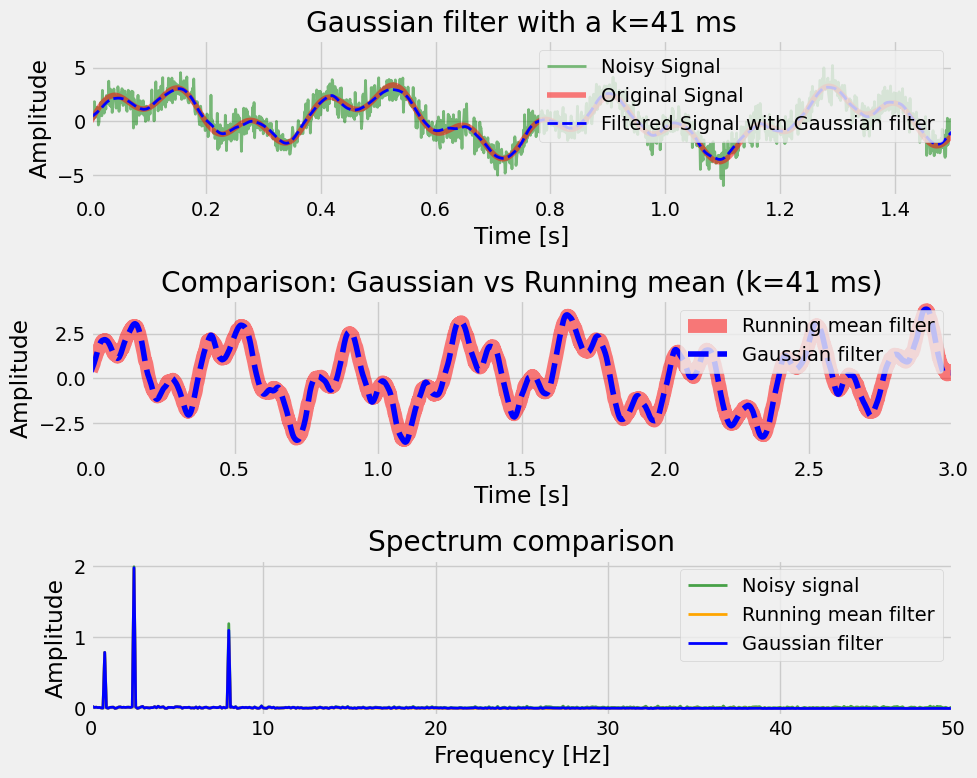

In [115]:
plt.figure(figsize=(10, 8))

# График 1: оригинал, шумный, Гаусс
plt.subplot(3, 1, 1)
plt.plot(t_vals, signal_vals_noise, 'g-', alpha=0.5, linewidth=2, label='Noisy Signal')
plt.plot(t_vals, signal_vals_1, 'r-', linewidth=4, alpha=0.5, label='Original Signal')
plt.plot(t_vals, signal_avg_gauss, 'b--', linewidth=2, label=f'Filtered Signal with Gaussian filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title(f'Gaussian filter with a k={k_ms} ms')
plt.legend(loc='upper right')
plt.xlim(0, 1.5)

# График 2: сравнение Гаусс vs Running mean
plt.subplot(3, 1, 2)
plt.plot(t_vals, signal_avg_mean, 'r', linewidth=10, alpha=0.5, label=f'Running mean filter')
plt.plot(t_vals, signal_avg_gauss, 'b--', linewidth=4, label=f'Gaussian filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title(f'Comparison: Gaussian vs Running mean (k={k_ms} ms)')
plt.legend(loc='upper right')
plt.xlim(0, 3)


# График 3: спектры (шумный, running mean, Гаусс)
plt.subplot(3, 1, 3)
plt.plot(f_noisy, spec_noisy, 'g-', alpha=0.7, linewidth=2, label='Noisy signal')
plt.plot(f_avg_mean, spec_avg_mean, 'orange', linewidth=2, label='Running mean filter')
plt.plot(f_avg_gauss, spec_avg_gauss, 'b-', linewidth=2, label='Gaussian filter')
plt.title('Spectrum comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, 50)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## <a id='toc1_3_'></a>[Task3](#toc0_)

Воспользоваться усреднением по Гауссу для обработки сигнала, состоящего из всплесков пиков. Всплеск каждого пика является случайной величиной. Амплитуда каждого пика $A = 1 \text{ V}$.


---

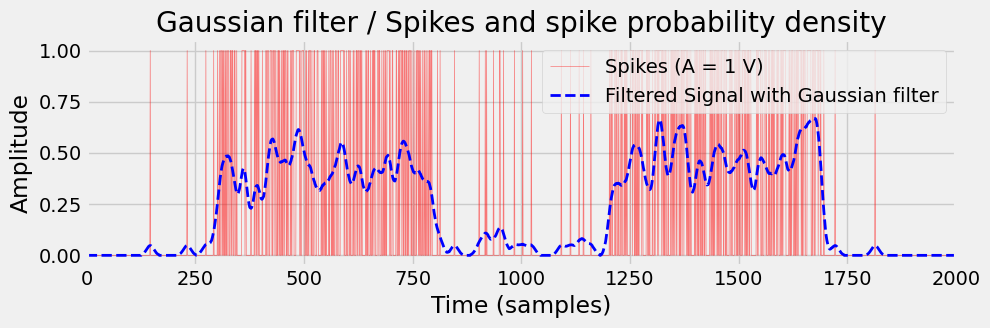

In [116]:
N = 2000
probabilities = np.zeros(N)

probabilities[0:300] = 0.02    
probabilities[300:800] = 0.40 
probabilities[800:1200] = 0.05 
probabilities[1200:1700] = 0.45 
probabilities[1700:2000] = 0.02 

spikes = (np.random.rand(N) < probabilities).astype(float) * 1.0

window_width = 41
filtered_signal = gauss_mean(spikes, window_width)


plt.figure(figsize=(10, 3.5))

plt.plot(np.arange(N), spikes, 'r', alpha=0.5, linewidth=0.5, label='Spikes (A = 1 V)')
plt.plot(np.arange(N), filtered_signal, 'b--', linewidth=2, label='Filtered Signal with Gaussian filter')

plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.title('Gaussian filter / Spikes and spike probability density')
plt.legend(loc='upper right')
plt.xlim(0, N)

plt.tight_layout()
plt.show()


## <a id='toc1_4_'></a>[Task4](#toc0_)
Реализовать медианный фильтр для очистки сигнала от случайных всплесков в сигнале. В этом случае амплитуда всплеска сигнала уже не является постоянной и является случайной величиной. Результат обработки представлен оранжевой линией на рис. 4.

> **Замечание:** Реализовать фильтрацию лучше в два этапа. Вначале ввести порог, выше которого пик будет удаляться, затем применить медианный фильтр.

### <a id='toc1_4_1_'></a>[Справка: Медианный фильтр для удаления импульсного шума (Spike Noise)](#toc0_)
Медианный фильтр — это **нелинейный** фильтр. Применяйте его к выбранным точкам данных, а не ко всем подряд.

**Пример работы:**
* Исходное окно: `{0, 1, 1, 2, 0, 3, 900}` $\rightarrow$ Среднее значение ($\text{Mean}$) = $129.57$, Медиана ($\text{Median}$) = $1$
* **Шаг 1:** Сортировка $\rightarrow$ `{0, 0, 1, 1, 2, 3, 900}`
* **Шаг 2:** Медиана = центральное значение списка $\rightarrow$ `1`

---


In [117]:
def median_filter(signal, window_width, percent_threshold=90, k_pre=15):
    processed_signal = signal.copy()
    
    def _preprocess():
        active_spikes = processed_signal[processed_signal > 0]
        if len(active_spikes) > 0:
            threshold = np.percentile(active_spikes, percent_threshold)
            processed_signal[processed_signal > threshold] = 0.0
            
        # Рассматриваем локальное окно вокруг каждой точки и берем среднее,
        # чтобы убрать 0.
        envelope_signal = np.zeros_like(processed_signal)
        for t in range(len(processed_signal)):
            left = max(0, t - k_pre)
            right = min(len(processed_signal), t + k_pre + 1)
            envelope_signal[t] = np.mean(processed_signal[left:right])
            
        return envelope_signal
        
    preprocessed_signal = _preprocess()
    
    result = np.zeros_like(preprocessed_signal)
    k = (window_width - 1) // 2
    
    for t in range(len(preprocessed_signal)):
        left = max(0, t - k)
        right = min(len(preprocessed_signal), t + k + 1)
        result[t] = np.median(preprocessed_signal[left:right])
    
    return result

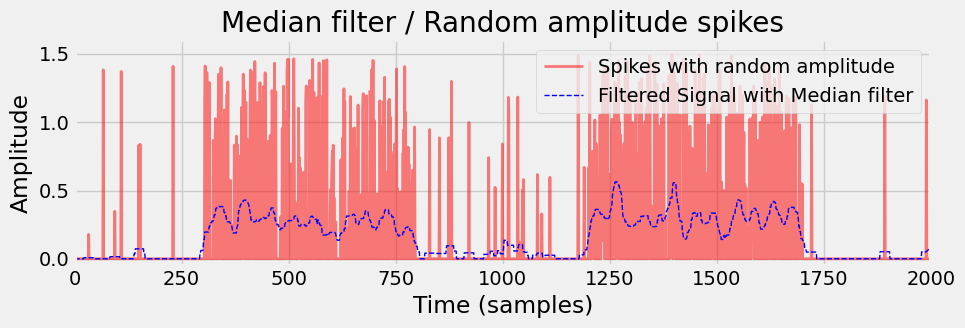

In [118]:
N = 2000
probabilities = np.zeros(N)

probabilities[0:300] = 0.02
probabilities[300:800] = 0.40
probabilities[800:1200] = 0.05
probabilities[1200:1700] = 0.45
probabilities[1700:2000] = 0.02

spike_locations = (np.random.rand(N) < probabilities).astype(float)

random_amplitudes = np.random.uniform(0.1, 1.5, N)

spikes_random_amp = spike_locations * random_amplitudes

window_width = 11
filtered_signal = median_filter(spikes_random_amp, window_width, k_pre=11)

plt.figure(figsize=(10, 3.5))

plt.plot(np.arange(N), spikes_random_amp, 'r-', alpha=0.5, linewidth=2, label='Spikes with random amplitude')
plt.plot(np.arange(N), filtered_signal, 'b--', linewidth=1, label='Filtered Signal with Median filter')

plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.title('Median filter / Random amplitude spikes')
plt.legend(loc='upper right')
plt.xlim(0, N)
plt.ylim(-0.05, 1.6)  

plt.tight_layout()
plt.show()

## <a id='toc1_5_'></a>[Task5](#toc0_)
Реализовать метод исключения линейного тренда из сигнала с использованием критерия Байесовской информации (BIC), как показано на рис. 5.

### <a id='toc1_5_1_'></a>[Справка: Критерий Байесовской информации (Bayes Information Criterion)](#toc0_)
Формула для вычисления $BIC$:
$$BIC = n \cdot \ln(\hat{\sigma}^2) + k \cdot \ln(n)$$
$$\hat{\sigma}^2 = n^{-1} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Где:
* $n$ — количество наблюдений в данных (`Data points`),

* $\hat{\sigma}^2$ — оценка дисперсии ошибок модели (среднеквадратичная ошибка между предсказанными данными $\hat{y}_i$ и реальными $y_i$),
* $k$ — количество параметров в модели (`Parameters`). Количество параметров модели $k$ будет определяться массивом выбранных степеней полиномов.


**Дополнительно:** Представить спектр исходного сигнала и сигнала, в котором был исключен тренд, объяснить результат сравнения.

---

In [119]:
def calculate_optimal_poly_trend(x, y, max_degree=6):

    N = len(y)
    degrees = np.arange(1, max_degree + 1)
    BIC_values = []
    
    best_BIC = np.inf
    best_degree = 1
    best_trend = None
    
    for d in degrees:
        coeffs = np.polyfit(x, y, d)
        fitted_trend = np.polyval(coeffs, x)
        
        mse = np.mean((y - fitted_trend) ** 2)
        k = d + 1
        
        BIC = N * np.log(mse) + k * np.log(N)
        BIC_values.append(BIC)
        
        if BIC < best_BIC:
            best_BIC = BIC
            best_degree = d
            best_trend = fitted_trend
            
    return best_trend, best_degree, np.array(BIC_values), degrees

In [125]:
np.random.seed(42)
N = 1000
t_vals = np.linspace(0, 10, N)

clean_signal = np.sin(2 * np.pi * 5 * t_vals) 

true_trend = 0.1 * t_vals**3 - 1.2 * t_vals**2 + 3.0 * t_vals + 5.0

noise = np.random.normal(0, 0.5, N)
signal_vals_noise = clean_signal + true_trend + noise

best_trend, best_degree, bic_values, degrees = calculate_optimal_poly_trend(t_vals, signal_vals_noise, max_degree=6)
best_bic = bic_values[np.argmin(bic_values)]
detrended_signal = signal_vals_noise - best_trend

dt = t_vals[1] - t_vals[0]
fs = 1.0 / dt  

freqs_noisy, spec_noisy = compute_spectrum(signal_vals_noise, fs)
freqs_detrended, spec_detrended = compute_spectrum(detrended_signal, fs)

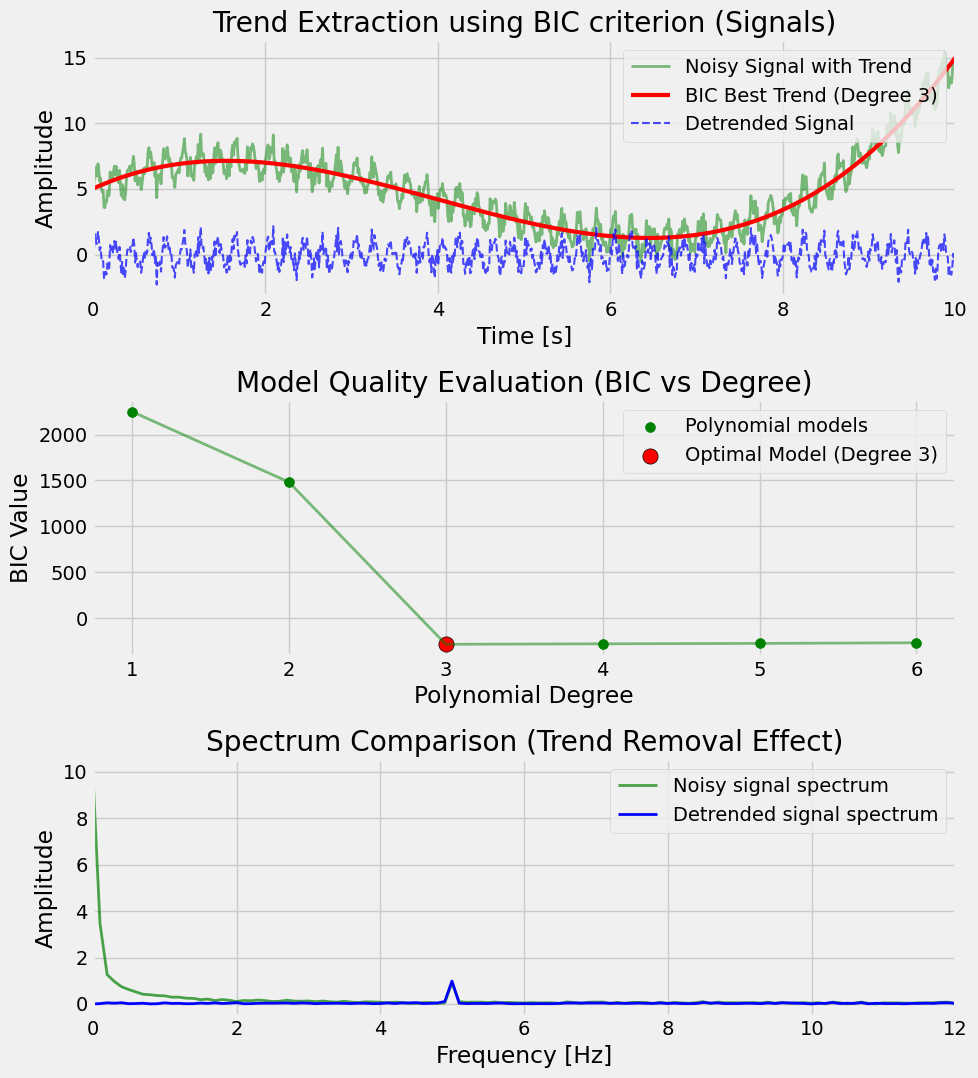

In [128]:
plt.figure(figsize=(10, 11))

plt.subplot(3, 1, 1)
plt.plot(t_vals, signal_vals_noise, 'g-', alpha=0.5, linewidth=2, label='Noisy Signal with Trend')
plt.plot(t_vals, best_trend, 'r-', linewidth=3, label=f'BIC Best Trend (Degree {best_degree})')
plt.plot(t_vals, detrended_signal, 'b--', linewidth=1.5, alpha=0.7, label='Detrended Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Trend Extraction using BIC criterion (Signals)')
plt.xlim(0, 10)
plt.legend(loc='upper right')

plt.subplot(3, 1, 2)
plt.plot(degrees, bic_values, 'g-', alpha=0.5, linewidth=2, zorder=2)
plt.scatter(degrees, bic_values, color='green', s=50, label='Polynomial models')
plt.scatter(best_degree, best_bic, color='red', s=120, edgecolors='black', label=f'Optimal Model (Degree {best_degree})')
plt.xlabel('Polynomial Degree')
plt.ylabel('BIC Value')
plt.title('Model Quality Evaluation (BIC vs Degree)')
plt.xticks(degrees)
plt.legend(loc='upper right')

plt.subplot(3, 1, 3)
plt.plot(freqs_noisy, spec_noisy, 'g-', alpha=0.7, linewidth=2, label='Noisy signal spectrum')
plt.plot(freqs_detrended, spec_detrended, 'b-', linewidth=2, label='Detrended signal spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Spectrum Comparison (Trend Removal Effect)')
plt.xlim(0, 12)  
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## <a id='toc1_6_'></a>[Task6](#toc0_)

Очистка ЭЭГ от артефактов с помощью регрессии

**Исходные данные**
Файл `templateProjection.mat` содержит:
* `EEGdat` — матрицу ЭЭГ (временные отсчёты $\times$ пробы);
* `eyedat` — матрицу ЭОГ (артефакт, временные отсчёты $\times$ пробы);
* `timevec` — вектор времени (мс).

```python
# Загрузка датасета в Python
import scipy.io as sio
matdat = sio.loadmat('templateProjection.mat')
EEGdat = matdat['EEGdat']
eyedat = matdat['eyedat']
```


In [9]:
import scipy.io as sio
matdat = sio.loadmat('templateProjection.mat')
EEGdat = matdat['EEGdat']
eyedat = matdat['eyedat']
timevec = matdat['timevec']
npnts = matdat['npnts']

matdat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'EEGdat', 'eyedat', 'npnts', 'timevec'])

In [10]:
print(type(EEGdat))
print(type(eyedat))
print(type(timevec))
print(type(npnts))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [11]:
print(EEGdat.shape)
print(eyedat.shape)
print(timevec.shape)
print(npnts.shape)

(1500, 707)
(1500, 707)
(1, 1500)
(1, 1)


In [12]:
timevec = timevec.flatten()

**Матричная форма линейной регрессии была разобрана в рамках курса «Теория Статистических решений. Осеннний семестр. ИИР III курс»**

[Лабораторная работа №3](https://github.com/ilushka-obnimashka/Statistical_decision_theory/blob/master/3lab.ipynb)

In [13]:
import pandas as pd

class LinearRegression:
    def __init__(self):
        self.weights = None
        self._feature_names = None
        
    def fit(self, df_or_X, y_or_target_col):
        # 1. Выделяем X и y
        if isinstance(df_or_X, pd.DataFrame):
            X = df_or_X.drop(columns=[y_or_target_col]).values
            y = df_or_X[y_or_target_col].values.reshape(-1, 1)
            self._feature_names = df_or_X.drop(columns=[y_or_target_col]).columns.tolist()
        else:
            X = df_or_X
            y = np.array(y_or_target_col).reshape(-1, 1)
            self._feature_names = [f'feature_{i}' for i in range(X.shape[1])]
        
        n_samples = X.shape[0]
        
        # 2. Добавляем единичный столбец для учета смещения (beta_0)
        X_with_intercept = np.column_stack([np.ones(n_samples), X]) 
        
        # 3. Считаем коэффициенты по формуле МНК: beta = (X^T * X)^(-1) * X^T * y
        try:
            self.weights = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y
        except np.linalg.LinAlgError:
            raise ValueError("Матрица (X.T @ X) вырожденная. Невозможно вычислить регрессию.")
            
        return self
        
    def predict(self, X_or_df):
        if self.weights is None:
            raise RuntimeError("Модель не обучена")

        if isinstance(X_or_df, pd.DataFrame):
            X = X_or_df[self._feature_names].values
        else:
            X = X_or_df

        n_samples = X.shape[0]
        X_with_intercept = np.column_stack([np.ones(n_samples), X])
        
        # Предсказание: y_pred = X * beta
        predictions = X_with_intercept @ self.weights
        return predictions.flatten()

In [16]:
cleanEEG = np.zeros_like(EEGdat)

for trial in range(707):
    y = EEGdat[:, trial]
    eye = eyedat[:, trial]
    X = np.column_stack([np.ones(1500), eye])
    df = pd.DataFrame({
        'EEG': y,
        'eye': eye
    })
    
    # Обучаем регрессию: EEG = β₀ + β₁ * eye
    model = LinearRegression()
    model.fit(df, 'EEG')      
    
    predicted_artifact = model.predict(df[['eye']])
    
    cleanEEG[:, trial] = y - predicted_artifact
    
eeg_mean = np.mean(EEGdat, axis=1)
eye_mean = np.mean(eyedat, axis=1)
clean_mean = np.mean(cleanEEG, axis=1)

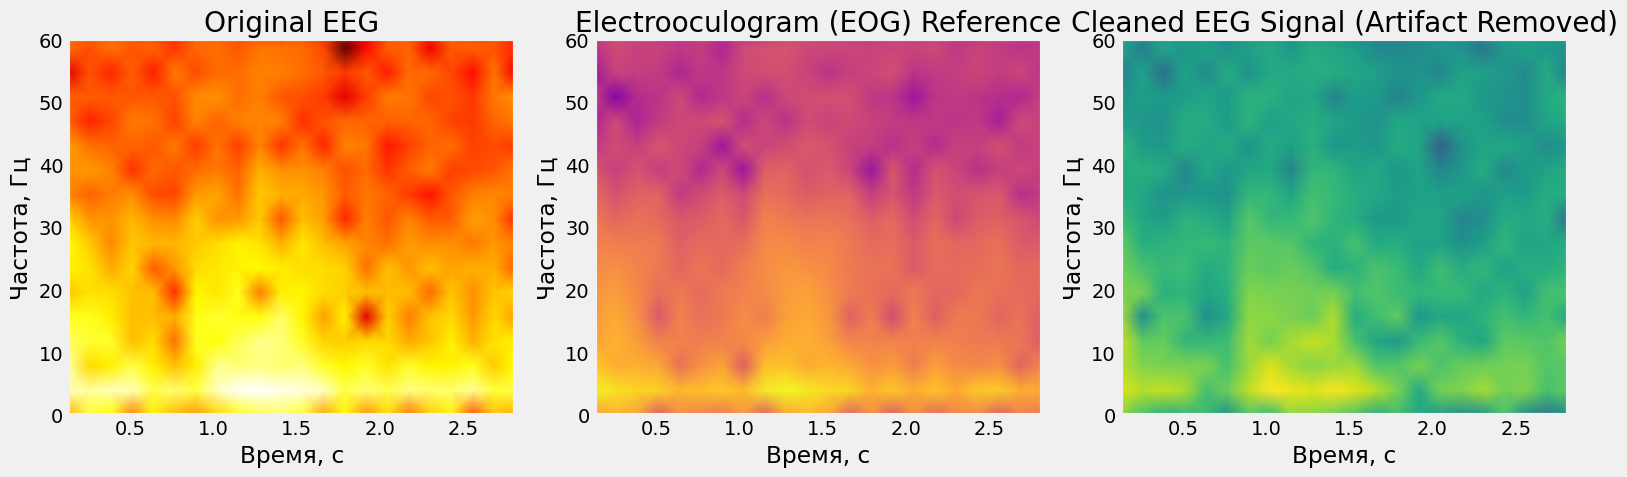

In [18]:
from scipy.signal import spectrogram

fs_eeg = 1000.0 * 1500 / (timevec[-1] - timevec[0]) if timevec[-1] != timevec[0] else 500.0

nperseg = 128

def plot_spectrogram(ax, sig, fs, title, cmap='hot'):
    f, t_spec, Sxx = spectrogram(sig, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    ax.pcolormesh(t_spec, f, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap=cmap)
    ax.set_ylim([0, 60])
    ax.set_ylabel('Частота, Гц'); ax.set_xlabel('Время, с')
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_spectrogram(axes[0], eeg_mean, fs_eeg, 'Original EEG')
plot_spectrogram(axes[1], eye_mean, fs_eeg, 'Electrooculogram (EOG) Reference', cmap='plasma')
plot_spectrogram(axes[2], clean_mean, fs_eeg, 'Cleaned EEG Signal (Artifact Removed)', cmap='viridis')
plt.tight_layout(); plt.show()
